In [29]:
# import numpy as np
# import pandas as pd
# from ta import add_all_ta_features
# from ta.volatility import AverageTrueRange, BollingerBands, UlcerIndex
# from ta.momentum import RSIIndicator, StochasticOscillator, WilliamsRIndicator
# from ta.trend import EMAIndicator, SMAIndicator, MACD, ADXIndicator, CCIIndicator, PSARIndicator
# from ta.volume import ForceIndexIndicator, VolumePriceTrendIndicator, ChaikinMoneyFlowIndicator, VolumeWeightedAveragePrice
# from ta.trend import AroonIndicator\
# from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [99]:
import numpy as np
import pandas as pd
import pandas_ta as ta
from pathlib import Path

from sklearn.preprocessing import StandardScaler

Path.cwd()

PosixPath('/Users/calebfowowe/Documents/Programming/ML_wrks/BlendingEnsembleProject/Tanyia_Project')

In [70]:
# Load the data and set the 'Date' column as the index
data = pd.read_csv("merged_df_final.csv", index_col='Date', parse_dates=True)

In [71]:
data

,Open,High,Low,Close,Volume,Eurozone - GDP per capita,USA - GDP per capita,Eurozone - GDP Growth Rate,USA - GDP Growth Rate,China - GDP Growth Rate,...,EUR/USD - 1 Month Vol,EUR/USD - 3 Month Vol,EUR/USD - 6 Month Vol,EUR/USD - 12 Month Vol,MarketValue,DividendYield,PriceToEarnings,EPS,PriceToCash,PriceToBook
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-01,115.640205,116.315478,115.513596,115.851227,563831,39731.0,55817.563,0.004,0.020383,0.073,...,8.3870,8.400,8.250,8.3250,76666.63,1.82,27.5,4.98,20.80,3.77
2014-12-02,116.273260,116.948534,115.724607,116.526489,628713,39731.0,55817.563,0.004,0.020383,0.073,...,8.8380,8.688,8.575,8.6250,77113.50,1.81,27.7,4.98,20.93,3.79
2014-12-03,116.231064,117.159567,116.188857,116.399879,519450,39731.0,55817.563,0.004,0.020383,0.073,...,8.9550,8.913,8.850,8.8500,77029.69,1.81,27.7,4.98,20.90,3.79
2014-12-04,116.231068,117.201778,114.289660,114.458488,1043572,39731.0,55817.563,0.004,0.020383,0.073,...,7.6250,8.363,8.337,8.4880,75744.94,1.84,27.2,4.98,20.55,3.72
2014-12-05,115.809004,117.412781,115.386960,117.412781,821623,39731.0,55817.563,0.004,0.020383,0.073,...,7.5500,8.375,8.450,8.5500,77700.00,1.80,27.9,4.98,21.09,3.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-25,332.899994,336.049988,329.850006,333.700012,724569,44814.0,65020.353,0.004,0.025123,0.046,...,8.3580,7.610,7.470,7.3900,178299.80,1.98,27.5,12.11,22.34,6.14
2024-11-26,331.149994,336.299988,328.399994,332.450012,322632,44814.0,65020.353,0.004,0.025123,0.046,...,8.3000,7.760,7.545,7.4420,177631.90,1.99,27.4,12.11,22.25,6.11
2024-11-27,331.000000,333.399994,329.649994,332.850006,300479,44814.0,65020.353,0.004,0.025123,0.046,...,8.4450,7.798,7.580,7.5100,177845.80,1.98,27.5,12.11,22.28,6.12


In [72]:
df = data.copy()

In [73]:
df

,Open,High,Low,Close,Volume,Eurozone - GDP per capita,USA - GDP per capita,Eurozone - GDP Growth Rate,USA - GDP Growth Rate,China - GDP Growth Rate,...,EUR/USD - 1 Month Vol,EUR/USD - 3 Month Vol,EUR/USD - 6 Month Vol,EUR/USD - 12 Month Vol,MarketValue,DividendYield,PriceToEarnings,EPS,PriceToCash,PriceToBook
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-01,115.640205,116.315478,115.513596,115.851227,563831,39731.0,55817.563,0.004,0.020383,0.073,...,8.3870,8.400,8.250,8.3250,76666.63,1.82,27.5,4.98,20.80,3.77
2014-12-02,116.273260,116.948534,115.724607,116.526489,628713,39731.0,55817.563,0.004,0.020383,0.073,...,8.8380,8.688,8.575,8.6250,77113.50,1.81,27.7,4.98,20.93,3.79
2014-12-03,116.231064,117.159567,116.188857,116.399879,519450,39731.0,55817.563,0.004,0.020383,0.073,...,8.9550,8.913,8.850,8.8500,77029.69,1.81,27.7,4.98,20.90,3.79
2014-12-04,116.231068,117.201778,114.289660,114.458488,1043572,39731.0,55817.563,0.004,0.020383,0.073,...,7.6250,8.363,8.337,8.4880,75744.94,1.84,27.2,4.98,20.55,3.72
2014-12-05,115.809004,117.412781,115.386960,117.412781,821623,39731.0,55817.563,0.004,0.020383,0.073,...,7.5500,8.375,8.450,8.5500,77700.00,1.80,27.9,4.98,21.09,3.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-25,332.899994,336.049988,329.850006,333.700012,724569,44814.0,65020.353,0.004,0.025123,0.046,...,8.3580,7.610,7.470,7.3900,178299.80,1.98,27.5,12.11,22.34,6.14
2024-11-26,331.149994,336.299988,328.399994,332.450012,322632,44814.0,65020.353,0.004,0.025123,0.046,...,8.3000,7.760,7.545,7.4420,177631.90,1.99,27.4,12.11,22.25,6.11
2024-11-27,331.000000,333.399994,329.649994,332.850006,300479,44814.0,65020.353,0.004,0.025123,0.046,...,8.4450,7.798,7.580,7.5100,177845.80,1.98,27.5,12.11,22.28,6.12


In [74]:
print(f"before creating Technical indicators features, the shape of the dataframe is: {df.shape}")
df.ta.study("All", lookahead=False, talib=False) #Create all technical indicators from Pandas_ta
print(f"After creating Technical indicators features, the shape of the dataframe is: {df.shape}")

df2 = df.copy() #Take a copy of dataframe created with the technical indicators
print(f"After taking a copy df into df2 with the technical indicators features, the shape of the dataframe is: {df2.shape}")

df2.drop(['QQEl_14_5_4.236', 'QQEs_14_5_4.236', 'PSARl_0.02_0.2', 'PSARs_0.02_0.2', 'PSARaf_0.02_0.2', 'HILOs_13_21','HILOl_13_21', 'PSARr_0.02_0.2', 'SUPERTl_7_3.0', 'SUPERTs_7_3.0', 'SUPERTd_7_3.0', 'SUPERT_7_3.0', 'ZIGZAGs_5.0%_10', 'ZIGZAGv_5.0%_10', 'ZIGZAGd_5.0%_10', 'VIDYA_14', 'VHM_610', 'PVIe_255', 'VWAP_D'], axis=1, inplace=True) # Drop unwanted columns (features)

print(f"After removing the initial unwanted/known problematic features from df2, the shape of the dataframe is: {df2.shape}")

# Drop columns with infinity values
# drop columns with infinity as values within them
specific_value = np.inf
specific_value2 = -np.inf
cols_with_infinity_values = [col for col in df2.columns if specific_value in df2[col].values or specific_value2 in df2[col].values]
df2.drop(columns=cols_with_infinity_values, axis=1, inplace=True)

print(f"After removing the feature column(s) from df2 which have infinity values within them, the shape of the dataframe is: {df2.shape}")

df3 = df2.copy()
print(f"After making a copy of the corrected dataframe2, into df3, the shape of the dataframe(df3) is: {df3.shape}")

before creating Technical indicators features, the shape of the dataframe is: (2562, 28)
After creating Technical indicators features, the shape of the dataframe is: (2562, 362)
After taking a copy df into df2 with the technical indicators features, the shape of the dataframe is: (2562, 362)
After removing the initial unwanted/known problematic features from df2, the shape of the dataframe is: (2562, 343)
After removing the feature column(s) from df2 which have infinity values within them, the shape of the dataframe is: (2562, 342)
After making a copy of the corrected dataframe2, into df3, the shape of the dataframe(df3) is: (2562, 342)


In [75]:
# # 1. **RSI (Relative Strength Index)**
# features_df['RSI'] = RSIIndicator(close=features_df['Close'], window=14).rsi()
# 
# # 2. **EMA (Exponential Moving Average)**
# features_df['EMA_12'] = EMAIndicator(close=features_df['Close'], window=12).ema_indicator()
# features_df['EMA_26'] = EMAIndicator(close=features_df['Close'], window=26).ema_indicator()
# 
# # 3. **SMA (Simple Moving Average)**
# features_df['SMA_50'] = SMAIndicator(close=features_df['Close'], window=50).sma_indicator()
# features_df['SMA_200'] = SMAIndicator(close=features_df['Close'], window=200).sma_indicator()
# 
# # 4. **MACD (Moving Average Convergence Divergence)**
# macd = MACD(close=features_df['Close'], window_slow=26, window_fast=12)
# features_df['MACD'] = macd.macd()
# features_df['MACD_signal'] = macd.macd_signal()
# 
# # 5. **Bollinger Bands**
# bb = BollingerBands(close=features_df['Close'], window=20, window_dev=2)
# features_df['BB_high'] = bb.bollinger_hband()
# features_df['BB_low'] = bb.bollinger_lband()
# 
# # 6. **ADX (Average Directional Index)**
# adx = ADXIndicator(high=features_df['High'], low=features_df['Low'], close=features_df['Close'], window=14)
# features_df['ADX'] = adx.adx()
# 
# # 7. **ATR (Average True Range)**
# atr = AverageTrueRange(high=features_df['High'], low=features_df['Low'], close=features_df['Close'], window=14)
# features_df['ATR'] = atr.average_true_range()
# 
# # 8. **Log Returns**
# features_df['log_returns'] = np.log(features_df['Close'] / features_df['Close'].shift(1))
# 
# # 9. **Lagged Returns**
# for lag in [5, 10, 14, 28]:
#     features_df[f'lagged_return_{lag}'] = features_df['Close'].pct_change(periods=lag)
# 
# # 10. **H-L (High - Low)**
# features_df['H_L'] = features_df['High'] - features_df['Low']
# 
# # 11. **O-C (Open - Close)**
# features_df['O_C'] = features_df['Open'] - features_df['Close']
# 
# # 12. **Momentum Indicators**
# features_df['momentum_5'] = features_df['Close'] - features_df['Close'].shift(5)
# features_df['momentum_10'] = features_df['Close'] - features_df['Close'].shift(10)
# 
# # 13. **Stochastic Oscillator**
# stoch = StochasticOscillator(close=features_df['Close'], high=features_df['High'], low=features_df['Low'], window=14, smooth_window=3)
# features_df['stochastic_oscillator'] = stoch.stoch()
# 
# # 14. **Williams %R**
# features_df['Williams_%R'] = WilliamsRIndicator(high=features_df['High'], low=features_df['Low'], close=features_df['Close'], lbp=14).williams_r()
# 
# # 15. **On-Balance Volume (OBV)**
# obv = features_df['Volume'] * np.sign(features_df['Close'].diff())
# features_df['OBV'] = obv.cumsum()
# 
# # 16. **Chaikin Money Flow (CMF)**
# cmf = ((features_df['Close'] - features_df['Low']) - (features_df['High'] - features_df['Close'])) / (features_df['High'] - features_df['Low']) * features_df['Volume']
# features_df['CMF'] = cmf.rolling(window=20).sum() / features_df['Volume'].rolling(window=20).sum()
# 
# # 17. **Parabolic SAR**
# psar = PSARIndicator(high=features_df['High'], low=features_df['Low'], close=features_df['Close'], step=0.02, max_step=0.2)
# features_df['PSAR'] = psar.psar()
# features_df['PSAR_down_indicator'] = psar.psar_down_indicator()
# features_df['PSAR_up_indicator'] = psar.psar_up_indicator()
# 
# # 18. **Day of the Week**
# features_df['day_of_week'] = features_df.index.dayofweek
# 
# # 19. **EMA crossovers**
# features_df['EMA_crossover_12_26'] = np.where(features_df['EMA_12'] > features_df['EMA_26'], 1, 0)
# 
# # Additional Indicators
# vpt = VolumePriceTrendIndicator(close=features_df['Close'], volume=features_df['Volume'])
# features_df['VPT'] = vpt.volume_price_trend()
# 
# force_index = ForceIndexIndicator(close=features_df['Close'], volume=features_df['Volume'], window=13)
# features_df['Force_Index'] = force_index.force_index()
# 
# mfi = ChaikinMoneyFlowIndicator(high=features_df['High'], low=features_df['Low'], close=features_df['Close'], volume=features_df['Volume'], window=14)
# features_df['MFI'] = mfi.chaikin_money_flow()
# 
# vwap = VolumeWeightedAveragePrice(high=features_df['High'], low=features_df['Low'], close=features_df['Close'], volume=features_df['Volume'], window=14)
# features_df['VWAP'] = vwap.volume_weighted_average_price()
# 
# cci = CCIIndicator(high=features_df['High'], low=features_df['Low'], close=features_df['Close'], window=20)
# features_df['CCI'] = cci.cci()

In [76]:
# # Calculate Aroon Up, Aroon Down, and Aroon Indicator
# features_df['Aroon_Up'] = AroonIndicator(high=features_df['High'], low=features_df['Low'], window=14).aroon_up()
# features_df['Aroon_Down'] = AroonIndicator(high=features_df['High'], low=features_df['Low'], window=14).aroon_down()
# features_df['Aroon_Indicator'] = AroonIndicator(high=features_df['High'], low=features_df['Low'], window=14).aroon_indicator()


In [77]:
# # Log Returns for Brent Futures
# features_df['Brent_Futures_1M_log_return'] = np.log(features_df['Brent Futures - 1 Month'] / features_df['Brent Futures - 1 Month'].shift(1))
# features_df['Brent_Futures_2M_log_return'] = np.log(features_df['Brent Futures - 2 Month'] / features_df['Brent Futures - 2 Month'].shift(1))
# features_df['Brent_Futures_3M_log_return'] = np.log(features_df['Brent Futures - 3 Month'] / features_df['Brent Futures - 3 Month'].shift(1))
# features_df['Brent_Futures_6M_log_return'] = np.log(features_df['Brent Futures - 6 Month'] / features_df['Brent Futures - 6 Month'].shift(1))
# 
# # Rolling Averages (7, 30, 90-day)
# features_df['Brent_Futures_1M_7d_avg'] = features_df['Brent Futures - 1 Month'].rolling(window=7).mean()
# features_df['Brent_Futures_2M_7d_avg'] = features_df['Brent Futures - 2 Month'].rolling(window=7).mean()
# features_df['Brent_Futures_3M_7d_avg'] = features_df['Brent Futures - 3 Month'].rolling(window=7).mean()
# features_df['Brent_Futures_6M_7d_avg'] = features_df['Brent Futures - 6 Month'].rolling(window=7).mean()
# 
# # Volatility of Brent Futures (Standard deviation of log returns)
# features_df['Brent_Futures_1M_volatility'] = features_df['Brent_Futures_1M_log_return'].rolling(window=14).std()
# features_df['Brent_Futures_2M_volatility'] = features_df['Brent_Futures_2M_log_return'].rolling(window=14).std()
# features_df['Brent_Futures_3M_volatility'] = features_df['Brent_Futures_3M_log_return'].rolling(window=14).std()
# features_df['Brent_Futures_6M_volatility'] = features_df['Brent_Futures_6M_log_return'].rolling(window=14).std()
# 
# # Rate of Change (Momentum) for Brent Futures
# features_df['Brent_Futures_1M_rate_of_change'] = features_df['Brent Futures - 1 Month'].pct_change(periods=7)
# features_df['Brent_Futures_2M_rate_of_change'] = features_df['Brent Futures - 2 Month'].pct_change(periods=7)
# features_df['Brent_Futures_3M_rate_of_change'] = features_df['Brent Futures - 3 Month'].pct_change(periods=7)
# features_df['Brent_Futures_6M_rate_of_change'] = features_df['Brent Futures - 6 Month'].pct_change(periods=7)


In [78]:
# # Calculate the rolling volatility of EUR/USD
# features_df['EUR_USD_1M_volatility'] = features_df['EUR/USD - 1 Month Vol'].rolling(window=14).std()
# features_df['EUR_USD_3M_volatility'] = features_df['EUR/USD - 3 Month Vol'].rolling(window=14).std()
# features_df['EUR_USD_6M_volatility'] = features_df['EUR/USD - 6 Month Vol'].rolling(window=14).std()
# features_df['EUR_USD_12M_volatility'] = features_df['EUR/USD - 12 Month Vol'].rolling(window=14).std()
# 
# # Calculate the percentage change for each volatility measure
# features_df['VROC_1m'] = features_df['EUR/USD - 1 Month Vol'].pct_change() * 100
# features_df['VROC_3m'] = features_df['EUR/USD - 3 Month Vol'].pct_change() * 100
# features_df['VROC_6m'] = features_df['EUR/USD - 6 Month Vol'].pct_change() * 100
# features_df['VROC_12m'] = features_df['EUR/USD - 12 Month Vol'].pct_change() * 100
# 
# # Compute the Ulcer Index (UI) for the EUR/USD Close prices
# features_df['UlcerIndex'] = UlcerIndex(close=features_df['EUR/USD Rates'], window=14).ulcer_index()
# 
# window = 21  # Example moving average window size
# features_df['DPO'] = features_df['EUR/USD Rates'] - features_df['EUR/USD Rates'].rolling(window=window).mean()

In [79]:
# # 2. Price to Earnings to Dividend Ratio
# features_df['PE_to_Dividend'] = features_df['PriceToEarnings'] / features_df['DividendYield']
# 
# # 3. Price to Earnings to Price to Book Combined Ratio
# features_df['PE_to_PB'] = features_df['PriceToEarnings'] / features_df['PriceToBook']
# 
# # 4. Price to Cash to Earnings Combined Feature
# features_df['PC_to_E'] = features_df['PriceToCash'] / features_df['PriceToEarnings']
# 
# # 5. Combined Valuation Metric (CWM)
# features_df['CWM'] = (features_df['PriceToEarnings'] / features_df['PriceToBook']) * (features_df['PriceToCash'] / features_df['PriceToEarnings'])
# 
# # 6. On-Balance Volume (OBV)
# features_df['OBV'] = (features_df['Volume'] * (features_df['Close'] > features_df['Close'].shift(1))).cumsum() - (features_df['Volume'] * (features_df['Close'] < features_df['Close'].shift(1))).cumsum()
# 
# # 7. Price Volume Trend (PVT)
# features_df['PVT'] = ((features_df['Close'] - features_df['Close'].shift(1)) / features_df['Close'].shift(1)) * features_df['Volume']
# features_df['PVT'] = features_df['PVT'].cumsum()

In [80]:
print(f"before creating Fundamental features, the shape of the dataframe is: {df3.shape}")

before creating Fundamental features, the shape of the dataframe is: (2562, 342)


In [81]:
# 2. Price to Earnings to Dividend Ratio
df3['PE_to_Dividend'] = df3['PriceToEarnings'] / df3['DividendYield']

# 3. Price to Earnings to Price to Book Combined Ratio
df3['PE_to_PB'] = df3['PriceToEarnings'] / df3['PriceToBook']

# 4. Price to Cash to Earnings Combined Feature
df3['PC_to_E'] = df3['PriceToCash'] / df3['PriceToEarnings']

# 5. Combined Valuation Metric (CWM)
df3['CWM'] = (df3['PriceToEarnings'] / df3['PriceToBook']) * (df3['PriceToCash'] / df3['PriceToEarnings'])

# 6. On-Balance Volume (OBV)
df3['OBV'] = (df3['Volume'] * (df3['Close'] > df3['Close'].shift(1))).cumsum() - (df3['Volume'] * (df3['Close'] < df3['Close'].shift(1))).cumsum()

# 7. Price Volume Trend (PVT)
df3['PVT'] = ((df3['Close'] - df3['Close'].shift(1)) / df3['Close'].shift(1)) * df3['Volume']
df3['PVT'] = df3['PVT'].cumsum()

print(f"After creating Fundamental features, the shape of the dataframe is: {df3.shape}")

After creating Fundamental features, the shape of the dataframe is: (2562, 346)


In [82]:
df4 = df3.copy()
print(f"After making a copy of the dataframe3, into df4, the shape of the dataframe(df4) is: {df4.shape}")
df4 = df4[100:]
print(f"After removing the NA rows, assuming that's the first 100rows, df4, shape is: {df4.shape}")

df4 =  df4.iloc[:-1]
print(f"After removing the last row df4, shape is: {df4.shape}")

After making a copy of the dataframe3, into df4, the shape of the dataframe(df4) is: (2562, 346)
After removing the NA rows, assuming that's the first 100rows, df4, shape is: (2462, 346)
After removing the last row df4, shape is: (2461, 346)


Recurrence plot is a great way to visualize time series data to uncover hidden patterns, periodicity, or self-similarity. A recurrence plot is often used in analyzing dynamical systems, and it visualizes the times at which a state in a dynamical system recurs.

The recurrence plot itself is a binary matrix where values of 1 indicate recurrence and 0 means no recurrence. 
Percentage of Recurrence: How often the system recurs within a certain time window.
Entropy: How complex the system is, based on the plot.

The Close price data is first normalized using StandardScaler to make sure all features are on the same scale.

The recurrence_plot function generates a binary recurrence plot using the Euclidean distance between each pair of points in the series.
If the distance between two points is smaller than the threshold, it is considered a recurrence, and the corresponding entry in the matrix is set to 1 (otherwise 0).

Feature Extraction:
Recurrence Percentage: This feature calculates the percentage of recurrence points in the plot. - This gives you an idea of how often the system shows self-similarity or recurrence.
Recurrence Entropy: A measure of the unpredictability or complexity of the recurrence plot, computed as the Shannon entropy of the recurrence matrix. - A higher value means the system exhibits more complex behavior, while a lower value indicates regular, predictable behavior.

In [83]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.spatial.distance import cdist
# from sklearn.preprocessing import StandardScaler
# 
# # Assuming 'features_df' is your DataFrame with a 'Close' column for time series data
# 
# # Normalize the data first (you may use other techniques)
# scaler = StandardScaler()
# data_scaled = scaler.fit_transform(features_df[['Close']])
# 
# # Create a Recurrence Plot function
# def recurrence_plot(data, threshold=0.1):
#     """
#     Generate a recurrence plot based on a distance threshold
#     :param data: Time series data (2D array or DataFrame)
#     :param threshold: Distance threshold for recurrence
#     :return: Recurrence plot (binary matrix)
#     """
#     distance_matrix = cdist(data, data, 'euclidean')
#     return (distance_matrix < threshold).astype(int)
# 
# # Generate Recurrence Plot for the 'Close' column
# rp = recurrence_plot(data_scaled)
# 
# # Visualize the Recurrence Plot
# plt.figure(figsize=(10, 8))
# plt.imshow(rp, cmap='binary', origin='lower', interpolation='none')
# plt.title('Recurrence Plot')
# plt.xlabel('Time')
# plt.ylabel('Time')
# plt.show()
# 
# # Create a feature from the recurrence plot:
# # Feature: Percentage of recurrence
# recurrence_percentage = np.sum(rp) / rp.size * 100
# 
# # Feature: Recurrence entropy
# def calculate_entropy(rp):
#     """Calculate entropy from the recurrence plot."""
#     prob_matrix = np.mean(rp, axis=0)
#     prob_nonzero = prob_matrix[prob_matrix > 0]
#     entropy = -np.sum(prob_nonzero * np.log(prob_nonzero))
#     return entropy
# 
# recurrence_entropy = calculate_entropy(rp)
# 
# # Add the new features to your DataFrame
# features_df['recurrence_percentage'] = recurrence_percentage
# features_df['recurrence_entropy'] = recurrence_entropy
# 
# # Check the result
# print(f"Recurrence Percentage: {recurrence_percentage}")
# print(f"Recurrence Entropy: {recurrence_entropy}")


Recurrance Percentage - Value: 8.18%
Interpretation: This indicates that about 8.18% of the points in the time series recur within a certain threshold (as defined by the Euclidean distance). This percentage reflects how often similar states occur in the time series.
A higher recurrence percentage suggests more frequent patterns, periodicity, or stability in the time series.
A lower recurrence percentage suggests less frequent repetition of similar patterns or more randomness in the time series.

Recurrence Entropy:
Value: 491.30
Interpretation: This is a measure of the complexity or unpredictability of the system. High entropy indicates a more complex and chaotic system, while lower entropy suggests more regular or predictable behavior.
A higher recurrence entropy value means that the system is more complex and irregular, indicating greater unpredictability or randomness in the data.
A lower recurrence entropy means that the system follows a more regular, deterministic pattern.

Making the Features More Useful for LSTM
To make the Recurrence Percentage and Recurrence Entropy more useful for LSTM models, here are some strategies:
Sliding Window Approach:
Instead of calculating a single global value (like for the entire dataset), compute these features over a sliding window of a certain size (e.g., over the last 30 days). This will create time-varying features that capture the recurrence dynamics at different points in time.

This results in a feature matrix where these values change over time, making them more useful for LSTM models, which need dynamic, time-dependent features.

LSTMs are well-suited to work with time-varying features because they capture temporal dependencies, so features that reflect changing patterns over time (such as rolling recurrence features) will provide more valuable insights.

In [84]:
# import numpy as np
# import pandas as pd
# from scipy.spatial.distance import cdist
# from sklearn.preprocessing import StandardScaler
# 
# # Assuming 'features_df' is your DataFrame with a 'Close' column for time series data
# 
# # Normalize the data (if not already done)
# scaler = StandardScaler()
# data_scaled = scaler.fit_transform(features_df[['Close']])
# 
# # Create a Recurrence Plot function
# def recurrence_plot(data, threshold=0.1):
#     """
#     Generate a recurrence plot based on a distance threshold
#     :param data: Time series data (2D array or DataFrame)
#     :param threshold: Distance threshold for recurrence
#     :return: Recurrence plot (binary matrix)
#     """
#     distance_matrix = cdist(data, data, 'euclidean')
#     return (distance_matrix < threshold).astype(int)
# 
# # Calculate Recurrence Features over a Sliding Window (e.g., 30-day window)
# window_size = 30
# recurrence_percentages = []
# recurrence_entropies = []
# 
# for i in range(window_size, len(features_df)):
#     window_data = data_scaled[i-window_size:i]
#     
#     # Generate the recurrence plot for the current window
#     rp = recurrence_plot(window_data)
#     
#     # Feature: Recurrence Percentage
#     recurrence_percentage = np.sum(rp) / rp.size * 100
#     recurrence_percentages.append(recurrence_percentage)
#     
#     # Feature: Recurrence Entropy
#     def calculate_entropy(rp):
#         """Calculate entropy from the recurrence plot."""
#         prob_matrix = np.mean(rp, axis=0)
#         prob_nonzero = prob_matrix[prob_matrix > 0]
#         entropy = -np.sum(prob_nonzero * np.log(prob_nonzero))
#         return entropy
# 
#     recurrence_entropy = calculate_entropy(rp)
#     recurrence_entropies.append(recurrence_entropy)
# 
# # Add the new features to the DataFrame
# features_df['recurrence_percentage'] = [None] * window_size + recurrence_percentages
# features_df['recurrence_entropy'] = [None] * window_size + recurrence_entropies
# 
# # Check the result
# print(features_df[['recurrence_percentage', 'recurrence_entropy']].head())


In [85]:
columns_with_na = df4.columns[df4.isna().any()].tolist()
print("Columns with NaN values:", columns_with_na)

Columns with NaN values: []


In [86]:
df4.tail()

,Open,High,Low,Close,Volume,Eurozone - GDP per capita,USA - GDP per capita,Eurozone - GDP Growth Rate,USA - GDP Growth Rate,China - GDP Growth Rate,...,TSVr_18_10,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30,PE_to_Dividend,PE_to_PB,PC_to_E,CWM
Date,,,,,,,,,,,,,,,,,,,,,
2024-11-22,324.149994,331.100006,323.100006,329.049988,477166,44814.0,65020.353,0.004,0.025123,0.046,...,0.729312,1312.299988,-65.679700,325.314546,323.169516,-0.964166,13.532338,4.495868,0.809559,3.639669
2024-11-25,332.899994,336.049988,329.850006,333.700012,724569,44814.0,65020.353,0.004,0.025123,0.046,...,0.415427,1333.300018,-53.162818,326.551821,327.220515,-0.681255,13.888889,4.478827,0.812364,3.638436
2024-11-26,331.149994,336.299988,328.399994,332.450012,322632,44814.0,65020.353,0.004,0.025123,0.046,...,0.274973,1329.600006,-45.531160,327.621822,330.398605,-0.705615,13.768844,4.484452,0.812044,3.641571
2024-11-27,331.000000,333.399994,329.649994,332.850006,300479,44814.0,65020.353,0.004,0.025123,0.046,...,0.360509,1328.750000,-43.898243,328.701823,332.653408,-0.629698,13.888889,4.493464,0.810182,3.640523
2024-11-28,333.000000,334.350006,328.549988,328.899994,226380,44814.0,65020.353,0.004,0.025123,0.046,...,0.425004,1320.699982,-48.571404,328.956367,331.943697,-0.834892,13.532338,4.495868,0.809191,3.638017


In [87]:
# Export the DataFrame to an Excel file
df4.to_excel('features_df.xlsx', index=False)

In [88]:
df4.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Eurozone - GDP per capita',
       'USA - GDP per capita', 'Eurozone - GDP Growth Rate',
       'USA - GDP Growth Rate', 'China - GDP Growth Rate',
       ...
       'TSVr_18_10', 'WCP', 'WILLR_14', 'WMA_10', 'ZL_EMA_10', 'ZS_30',
       'PE_to_Dividend', 'PE_to_PB', 'PC_to_E', 'CWM'],
      dtype='object', length=346)

In [89]:
# 1. Calculate the daily returns (percentage change)
df4['daily_return'] = df4['Close'].pct_change()

# 2. Label the 'y' variable as 1 (uptrend) if the return is positive, else 0 (downtrend)
df4['y'] = np.where(df4['daily_return'] > 0, 1, 0)

print(f"After creating returns and target columns, shape is: {df4.shape}")
# Now, 'y' is the binary target variable for the classification problem

After creating returns and target columns, shape is: (2461, 348)


In [17]:
# # 1. Calculate the daily returns (percentage change)
# features_df['daily_return'] = features_df['Close'].pct_change()
# 
# # 2. Label the 'y' variable as 1 (uptrend) if the return is positive, else 0 (downtrend)
# features_df['y'] = np.where(features_df['daily_return'] > 0, 1, 0)
# 
# # Now, 'y' is the binary target variable for the classification problem

In [ ]:
# # Check the total number of NaN values in each column
# nan_counts = features_df.isna().sum()
# 
# # Display the total NaN counts for each column
# print(nan_counts)

In [90]:
# Check the total number of NaN values in each column
nan_counts = df4.isna().sum()

# Display the total NaN counts for each column
print(nan_counts)

Open            0
High            0
Low             0
Close           0
Volume          0
               ..
PE_to_PB        0
PC_to_E         0
CWM             0
daily_return    1
y               0
Length: 348, dtype: int64


In [91]:
# Export the NaN counts to a CSV file
nan_counts.to_csv('nan_counts.csv', header=True)

# Output the path where the CSV file is saved
'nan_counts.csv'

'nan_counts.csv'

In [92]:
# Drop rows with NaN values and assign the result to a new dataframe
df5 = df4.copy()
print(f"before droping na row{df5.shape}")
df5.dropna(inplace=True)
print(f"After droping na row{df5.shape}")

# Display the updated DataFrame
df5

before droping na row(2461, 348)
After droping na row(2460, 348)


,Open,High,Low,Close,Volume,Eurozone - GDP per capita,USA - GDP per capita,Eurozone - GDP Growth Rate,USA - GDP Growth Rate,China - GDP Growth Rate,...,WILLR_14,WMA_10,ZL_EMA_10,ZS_30,PE_to_Dividend,PE_to_PB,PC_to_E,CWM,daily_return,y
Date,,,,,,,,,,,,,,,,,,,,,
2015-04-28,150.627684,150.880913,145.563150,146.871490,752047,39731.0,55817.563,0.008,0.036509,0.071,...,-82.485807,149.033893,148.465786,-0.100997,13.225806,4.963680,1.075122,5.336562,-0.029289,0
2015-04-29,146.913707,148.475264,142.819870,142.819870,820080,39731.0,55817.563,0.008,0.036509,0.071,...,-100.000000,147.842961,146.549125,-1.510264,12.437500,4.962594,1.077387,5.346633,-0.027586,0
2015-04-30,142.651043,145.183310,141.173887,143.874969,900945,39731.0,55817.563,0.008,0.036509,0.071,...,-77.224193,146.980455,145.249521,-1.091933,12.658228,4.950495,1.079500,5.344059,0.007388,1
2015-05-04,145.563158,147.124727,144.043795,146.322845,567817,39731.0,55817.563,0.008,0.036509,0.071,...,-56.583448,146.690397,144.539195,-0.255543,13.076923,4.963504,1.076471,5.343066,0.017014,1
2015-05-05,145.765496,148.037718,142.678692,142.935928,1111922,39731.0,55817.563,0.008,0.036509,0.071,...,-85.142286,145.829811,143.532135,-1.441733,12.098765,4.962025,1.077551,5.346835,-0.023147,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-22,324.149994,331.100006,323.100006,329.049988,477166,44814.0,65020.353,0.004,0.025123,0.046,...,-65.679700,325.314546,323.169516,-0.964166,13.532338,4.495868,0.809559,3.639669,0.019046,1
2024-11-25,332.899994,336.049988,329.850006,333.700012,724569,44814.0,65020.353,0.004,0.025123,0.046,...,-53.162818,326.551821,327.220515,-0.681255,13.888889,4.478827,0.812364,3.638436,0.014132,1
2024-11-26,331.149994,336.299988,328.399994,332.450012,322632,44814.0,65020.353,0.004,0.025123,0.046,...,-45.531160,327.621822,330.398605,-0.705615,13.768844,4.484452,0.812044,3.641571,-0.003746,0


In [20]:
# # Drop rows with NaN values and assign the result to a new dataframe
# features_df_nonull = features_df.dropna()
# 
# # Display the updated DataFrame
# features_df_nonull


,Open,High,Low,Close,Volume,Eurozone - GDP per capita,USA - GDP per capita,Eurozone - GDP Growth Rate,USA - GDP Growth Rate,China - GDP Growth Rate,...,DPO,PE_to_Dividend,PE_to_PB,PC_to_E,CWM,PVT,recurrence_percentage,recurrence_entropy,daily_return,y
Date,,,,,,,,,,,,,,,,,,,,,
2015-09-14,124.672368,126.172896,123.429077,123.429077,614370,34282.0,57040.208,0.004,0.016106,0.070,...,0.006938,8.510638,4.692082,1.140000,5.348974,-22330.590128,50.888889,9.996582,-0.009291,0
2015-09-15,123.814904,126.344374,123.514807,125.829903,763478,34282.0,57040.208,0.004,0.016106,0.070,...,0.000655,8.858696,4.683908,1.140491,5.341954,-7480.139215,52.000000,9.703028,0.019451,1
2015-09-16,126.901743,129.945673,126.387272,129.131104,790799,34282.0,57040.208,0.004,0.016106,0.070,...,0.001676,9.329609,4.677871,1.142515,5.344538,13266.807967,53.555556,9.315825,0.026235,1
2015-09-17,129.688402,129.902763,128.530847,129.045319,472916,34282.0,57040.208,0.004,0.016106,0.070,...,0.014867,9.329609,4.677871,1.141916,5.341737,12952.638442,56.444444,8.792343,-0.000664,0
2015-09-18,128.230748,128.616596,125.143945,125.829903,1506497,34282.0,57040.208,0.004,0.016106,0.070,...,0.001462,8.858696,4.683908,1.140491,5.341954,-24584.674355,60.000000,8.222599,-0.024917,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-25,332.899994,336.049988,329.850006,333.700012,724569,44814.0,65020.353,0.004,0.025123,0.046,...,-0.018683,13.888889,4.478827,0.812364,3.638436,310401.921362,30.888889,10.521165,0.014132,1
2024-11-26,331.149994,336.299988,328.399994,332.450012,322632,44814.0,65020.353,0.004,0.025123,0.046,...,-0.017788,13.768844,4.484452,0.812044,3.641571,309193.380801,32.888889,10.753656,-0.003746,0
2024-11-27,331.000000,333.399994,329.649994,332.850006,300479,44814.0,65020.353,0.004,0.025123,0.046,...,-0.008786,13.888889,4.493464,0.810182,3.640523,309554.908133,34.444444,10.719497,0.001203,1


In [21]:
# features_df_nonull.head()

,Open,High,Low,Close,Volume,Eurozone - GDP per capita,USA - GDP per capita,Eurozone - GDP Growth Rate,USA - GDP Growth Rate,China - GDP Growth Rate,...,DPO,PE_to_Dividend,PE_to_PB,PC_to_E,CWM,PVT,recurrence_percentage,recurrence_entropy,daily_return,y
Date,,,,,,,,,,,,,,,,,,,,,
2015-09-14,124.672368,126.172896,123.429077,123.429077,614370,34282.0,57040.208,0.004,0.016106,0.07,...,0.006938,8.510638,4.692082,1.140000,5.348974,-22330.590128,50.888889,9.996582,-0.009291,0
2015-09-15,123.814904,126.344374,123.514807,125.829903,763478,34282.0,57040.208,0.004,0.016106,0.07,...,0.000655,8.858696,4.683908,1.140491,5.341954,-7480.139215,52.000000,9.703028,0.019451,1
2015-09-16,126.901743,129.945673,126.387272,129.131104,790799,34282.0,57040.208,0.004,0.016106,0.07,...,0.001676,9.329609,4.677871,1.142515,5.344538,13266.807967,53.555556,9.315825,0.026235,1
2015-09-17,129.688402,129.902763,128.530847,129.045319,472916,34282.0,57040.208,0.004,0.016106,0.07,...,0.014867,9.329609,4.677871,1.141916,5.341737,12952.638442,56.444444,8.792343,-0.000664,0
2015-09-18,128.230748,128.616596,125.143945,125.829903,1506497,34282.0,57040.208,0.004,0.016106,0.07,...,0.001462,8.858696,4.683908,1.140491,5.341954,-24584.674355,60.000000,8.222599,-0.024917,0


In [22]:
# daily_return_description = features_df_nonull['daily_return'].describe()
# 
# print(daily_return_description)

count    2343.000000
mean        0.000509
std         0.014065
min        -0.075803
25%        -0.007019
50%         0.000570
75%         0.007702
max         0.084374
Name: daily_return, dtype: float64


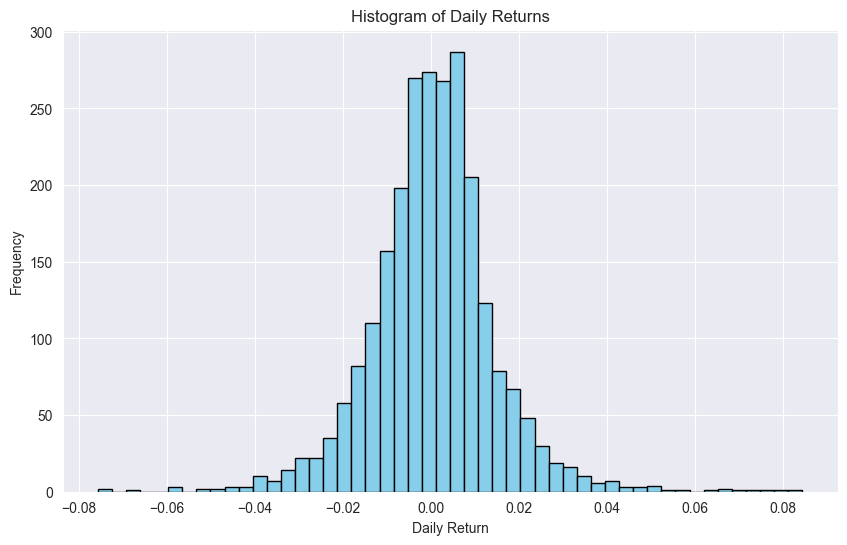

In [93]:
import matplotlib.pyplot as plt

# Plot histogram for the daily returns to understand the distribution
plt.figure(figsize=(10, 6))
plt.hist(df5['daily_return'], bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()


In [24]:
# # Calculate the variance of each feature (ignoring the target column 'y')
# feature_variance = features_df_nonull.drop('y', axis=1).var()
# 
# # Display the variance of each feature
# print(feature_variance)


Open                     9.982990e+03
High                     1.016593e+04
Low                      9.795565e+03
Close                    9.980313e+03
Volume                   5.910833e+10
                             ...     
CWM                      5.220230e-01
PVT                      1.852915e+10
recurrence_percentage    4.954696e+02
recurrence_entropy       1.619994e+01
daily_return             1.978291e-04
Length: 99, dtype: float64


In [25]:
# # Set the threshold for low variance
# variance_threshold = 0.001
# 
# # Identify low variance features
# low_variance_features = feature_variance[feature_variance < variance_threshold].index
# 
# print(f"Low variance features: {low_variance_features}")


Low variance features: Index(['Eurozone - GDP Growth Rate', 'Eurozone - Monthly CPI',
       'France - Monthly CPI', 'USA - Monthly CPI', 'log_returns',
       'lagged_return_5', 'Brent_Futures_1M_log_return',
       'Brent_Futures_2M_log_return', 'Brent_Futures_3M_log_return',
       'Brent_Futures_6M_log_return', 'Brent_Futures_1M_volatility',
       'Brent_Futures_2M_volatility', 'Brent_Futures_3M_volatility',
       'Brent_Futures_6M_volatility', 'DPO', 'daily_return'],
      dtype='object')


Even though a feature may exhibit low variance, it could still hold valuable information under certain conditions. For instance, a feature that mostly assumes a constant value but changes under specific circumstances could be highly informative about those conditions. Therefore, the decision to remove a low variance feature should be well-considered, weighing the potential loss of subtle but important data against the simplicity and efficiency gained by its exclusion.

In [26]:
# # Get summary statistics for all numerical features
# features_df_nonull.describe()


,Open,High,Low,Close,Volume,Eurozone - GDP per capita,USA - GDP per capita,Eurozone - GDP Growth Rate,USA - GDP Growth Rate,China - GDP Growth Rate,...,DPO,PE_to_Dividend,PE_to_PB,PC_to_E,CWM,PVT,recurrence_percentage,recurrence_entropy,daily_return,y
count,2343.000000,2343.000000,2343.000000,2343.000000,2.343000e+03,2343.000000,2343.000000,2343.000000,2343.000000,2343.000000,...,2343.000000,2343.000000,2343.000000,2343.000000,2343.000000,2343.000000,2343.000000,2343.000000,2343.000000,2343.000000
mean,264.638361,267.043498,262.169562,264.720154,4.802156e+05,39512.493811,60921.364211,0.004135,0.027099,0.056998,...,-0.000301,25.792610,6.637889,0.692935,4.508001,260442.317861,74.241950,5.140498,0.000509,0.519420
std,99.914914,100.826226,98.972546,99.901517,2.431220e+05,3374.280917,2682.017244,0.026553,0.077664,0.033058,...,0.012298,11.735962,1.323926,0.116954,0.722512,136121.838373,22.259147,4.024914,0.014065,0.499729
min,123.772056,125.615561,122.057165,123.386192,5.229300e+04,34282.000000,57040.208000,-0.108000,-0.280767,-0.069000,...,-0.040843,8.510638,4.478827,0.487154,3.635914,-80521.981563,26.666667,-0.000000,-0.075803,0.000000
25%,166.439713,167.662856,165.283242,166.484177,3.241740e+05,37060.000000,58703.144000,0.002000,0.019618,0.047000,...,-0.008132,17.112299,5.101358,0.615982,3.698184,143416.748130,54.666667,0.507914,-0.007019,0.000000
50%,243.288714,244.485791,240.894475,243.749146,4.280170e+05,39029.000000,60127.210000,0.005000,0.027555,0.063000,...,-0.000574,22.641509,6.920981,0.681065,5.058081,306403.692188,75.111111,5.635833,0.000570,1.000000
75%,355.901410,359.818903,352.337364,355.925034,5.701965e+05,42770.000000,63720.764000,0.007000,0.033827,0.069000,...,0.007749,31.936536,7.575758,0.737395,5.178142,375101.791337,98.222222,9.131940,0.007702,1.000000
max,457.950012,461.850006,456.149994,456.899994,2.569157e+06,44814.000000,65020.353000,0.108000,0.351954,0.187000,...,0.047288,63.225806,8.931860,1.143011,5.350000,453524.476764,100.000000,10.946127,0.084374,1.000000


In [27]:
# # Calculate skewness and kurtosis for each feature
# skewness = features_df_nonull.skew()
# kurtosis = features_df_nonull.kurtosis()
# 
# # Combine skewness and kurtosis into a single DataFrame
# skew_kurt_df = pd.DataFrame({
#     'Feature': features_df_nonull.columns,
#     'Skewness': skewness,
#     'Kurtosis': kurtosis
# })
# 
# # Save the DataFrame to a CSV file
# skew_kurt_df.to_csv('skewness_kurtosis_summary.csv', index=False)
# 
# # Optionally, print the first few rows to check the output
# print(skew_kurt_df.head())


       Feature  Skewness  Kurtosis
Open      Open  0.253637 -1.361276
High      High  0.246871 -1.370495
Low        Low  0.260204 -1.352231
Close    Close  0.252119 -1.361953
Volume  Volume  2.254064  9.822709


In [94]:
# Checking the class distribution in the 'y' column
y_class_distribution = df5['y'].value_counts()
print(y_class_distribution)

y
1    1273
0    1187
Name: count, dtype: int64


In [28]:
# # Checking the class distribution in the 'y' column
# y_class_distribution = features_df_nonull['y'].value_counts()
# print(y_class_distribution)


y
1    1217
0    1126
Name: count, dtype: int64


In [29]:
# print(features_df_nonull.isna().sum())

Open                     0
High                     0
Low                      0
Close                    0
Volume                   0
                        ..
PVT                      0
recurrence_percentage    0
recurrence_entropy       0
daily_return             0
y                        0
Length: 100, dtype: int64


In [95]:
df6 = df5.copy()
df6 = df6.astype(float)

In [96]:
# Calculate correlation between all features and the target 'y'
corr_matrix = df6.corr()

# Extract the correlation of each feature with the target 'y'
target_corr = corr_matrix['y'].sort_values(ascending=False)

# Display the correlation between each feature and 'y'
print(target_corr)

y               1.000000
INC_1           1.000000
CRSI_3_2_100    0.913157
LOGRET_1        0.720566
PCTRET_1        0.719726
                  ...   
CDL_MATHOLD          NaN
SQZ_NO               NaN
SQZPRO_NO            NaN
TMOM_14_5_3          NaN
TMOMs_14_5_3         NaN
Name: y, Length: 348, dtype: float64


In [102]:
target_corr

y               1.000000
INC_1           1.000000
CRSI_3_2_100    0.913157
LOGRET_1        0.720566
PCTRET_1        0.719726
                  ...   
CDL_MATHOLD          NaN
SQZ_NO               NaN
SQZPRO_NO            NaN
TMOM_14_5_3          NaN
TMOMs_14_5_3         NaN
Name: y, Length: 348, dtype: float64

In [31]:
# # Calculate correlation between all features and the target 'y'
# corr_matrix = features_df_nonull.corr()
# 
# # Extract the correlation of each feature with the target 'y'
# target_corr = corr_matrix['y'].sort_values(ascending=False)
# 
# # Display the correlation between each feature and 'y'
# print(target_corr)


y                        1.000000
log_returns              0.718843
daily_return             0.717842
stochastic_oscillator    0.374968
Williams_%R              0.374968
                           ...   
PSAR_down_indicator     -0.142761
VROC_3m                 -0.159618
VROC_12m                -0.161197
VROC_6m                 -0.171728
O_C                     -0.585255
Name: y, Length: 100, dtype: float64


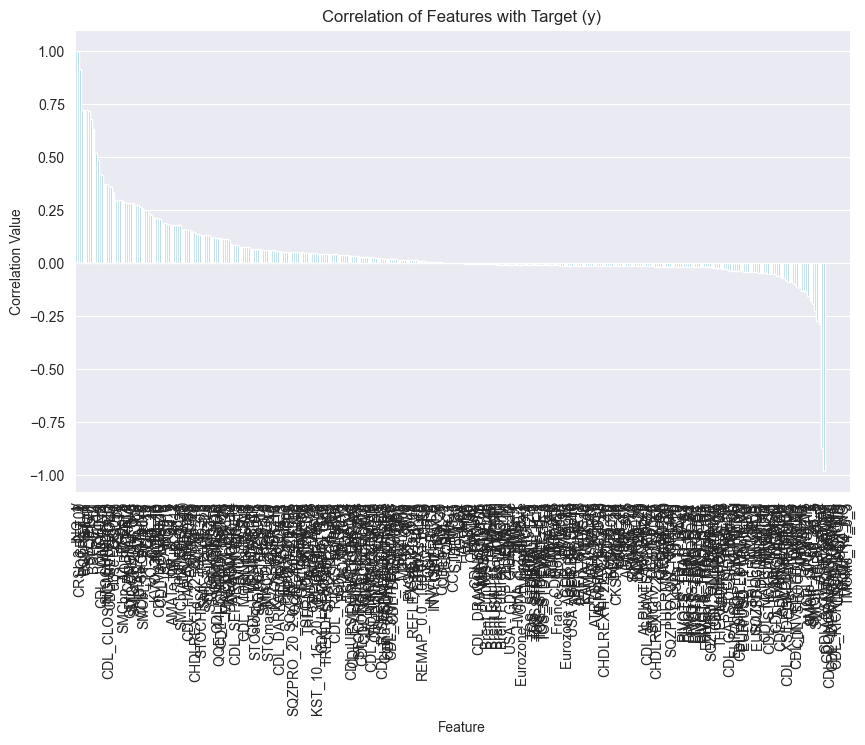

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 3: Plot the correlation of features with 'y'
plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.index, y=target_corr.values, color='skyblue')  # Using color instead of palette
plt.title('Correlation of Features with Target (y)')
plt.xlabel('Feature')
plt.ylabel('Correlation Value')
plt.xticks(rotation=90)  # Rotate feature names for readability
plt.show()

In [33]:
# # Step 4: Remove highly correlated features (correlation > 0.9)
# # Exclude the target 'y' from the correlation calculation
# features_without_y = features_df_nonull.drop('y', axis=1)
# 
# # Calculate the correlation matrix of the features excluding 'y'
# corr_matrix = features_without_y.corr()
# 
# # Find the features with high correlation with 'y' (threshold = 0.9)
# high_corr_features = target_corr[abs(target_corr) > 0.9].index
# 
# # Ensure that 'y' is not removed by excluding it from the drop list
# high_corr_features = [feature for feature in high_corr_features if feature != 'y']
# 
# # Remove the features with high correlation (except for 'y')
# features_df_cleaned = features_df_nonull.drop(columns=high_corr_features)
# 
# # Display the cleaned DataFrame shape
# print(f"Shape before removing features: {features_df_nonull.shape}")
# print(f"Shape after removing features: {features_df_cleaned.shape}")


Shape before removing features: (2343, 100)
Shape after removing features: (2343, 100)


In [34]:
# # List columns with NaN values
# columns_with_na = features_df_cleaned.columns[features_df_cleaned.isna().any()].tolist()
# 
# # Display the columns with NaN values
# columns_with_na

[]

In [101]:
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline

# Load your data
# Assuming 'features_df_cleaned' is your DataFrame and 'y' is the target variable
X = df6.drop(columns=['y', 'Open', 'High', 'Low', 'Close', 'Volume', 'daily_return', 'Eurozone - GDP per capita', 'USA - GDP per capita',
       'Eurozone - GDP Growth Rate', 'USA - GDP Growth Rate',
       'China - GDP Growth Rate', 'Eurozone - Monthly CPI',
       'France - Monthly CPI', 'USA - Monthly CPI', 'Brent Futures - 1 Month',
       'Brent Futures - 2 Month', 'Brent Futures - 3 Month',
       'Brent Futures - 6 Month', 'EUR/USD Rates', 'EUR/USD - 1 Month Vol',
       'EUR/USD - 3 Month Vol', 'EUR/USD - 6 Month Vol',
       'EUR/USD - 12 Month Vol', 'MarketValue', 'DividendYield',
       'PriceToEarnings', 'EPS', 'PriceToCash', 'PriceToBook', 'INC_1', 'CRSI_3_2_100', 'LOGRET_1', 'PCTRET_1'])  
y = df6['y']  

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
X_train, X_test, y_train, y_test = np.array(X_train), np.array(X_test), np.array(y_train), np.array(y_test)

# # Step 1: 
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)
rf_pipe = Pipeline([
            ('transformer', StandardScaler()),
            ('classifier', rf)
        ])

# Train a Random Forest model
rf_pipe.fit(X_train, y_train)
y_pred = rf_pipe.predict(X_test)

# Metrics for Boruta
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(acc, f1)

0.9959349593495935 0.9959349593495935


In [103]:
X.columns

Index(['ABER_ZG_5_15', 'ABER_SG_5_15', 'ABER_XG_5_15', 'ABER_ATR_5_15',
       'ACCBL_20', 'ACCBM_20', 'ACCBU_20', 'AD', 'ADOSC_3_10', 'ADX_14',
       ...
       'TSVr_18_10', 'WCP', 'WILLR_14', 'WMA_10', 'ZL_EMA_10', 'ZS_30',
       'PE_to_Dividend', 'PE_to_PB', 'PC_to_E', 'CWM'],
      dtype='object', length=314)

In [104]:

# X = features_df_cleaned.drop(columns=['y', 'Open', 'High', 'Low', 'Close', 'Volume', 'daily_return'])  
# y = features_df_cleaned['y']  

# # Split data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

features_list = X.columns

# Step 1: Boruta Feature Selection
rf_boruta = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)
boruta = BorutaPy(rf_boruta, n_estimators='auto', random_state=42, verbose=0, max_iter=100)
boruta.fit(X_train, y_train)

# # Select Boruta features
# boruta_features = X_train.columns[boruta.support_].tolist()
# X_train_boruta = X_train[boruta_features]
# X_test_boruta = X_test[boruta_features]

# find all Boruta selected features from the feature set.
boruta_selected_features = list(features_list[boruta.support_])

# call transform() on X to filter down to selected features in both training and test set.
X_train_filtered = boruta.transform(X_train)
X_test_filtered = boruta.transform(X_test)

# Train a Random Forest model
rf_pipe.fit(X_train_filtered, y_train)
y_pred_boruta = rf_pipe.predict(X_test_filtered)

# Metrics for Boruta
acc_boruta = accuracy_score(y_test, y_pred_boruta)
f1_boruta = f1_score(y_test, y_pred_boruta)

print(acc_boruta, f1_boruta)

# # Step 2: Recursive Feature Elimination (RFE)
# rfe = RFE(estimator=rf, n_features_to_select=10)  # Adjust number of features as desired
# rfe.fit(X_train_boruta, y_train)

# # Select RFE features
# rfe_features = X_train_boruta.columns[rfe.support_].tolist()
# X_train_rfe = X_train_boruta[rfe_features]
# X_test_rfe = X_test_boruta[rfe_features]

# # Train a Random Forest model
# rf.fit(X_train_rfe, y_train)
# y_pred_rfe = rf.predict(X_test_rfe)

# # Metrics for RFE
# acc_rfe = accuracy_score(y_test, y_pred_rfe)
# f1_rfe = f1_score(y_test, y_pred_rfe)

# # Step 3: Multicollinearity Filtering
# correlation_matrix = X_train_rfe.corr().abs()
# upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# # Drop features with correlation > 0.9
# to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]
# X_train_multicollinear = X_train_rfe.drop(columns=to_drop)
# X_test_multicollinear = X_test_rfe.drop(columns=to_drop)

# # Train a Random Forest model
# rf.fit(X_train_multicollinear, y_train)
# y_pred_multicollinear = rf.predict(X_test_multicollinear)

# # Metrics for Multicollinearity Filtering
# acc_multicollinear = accuracy_score(y_test, y_pred_multicollinear)
# f1_multicollinear = f1_score(y_test, y_pred_multicollinear)

# # Summary of feature selection
# summary = pd.DataFrame({
#     'Stage': ['Boruta', 'RFE', 'Multicollinearity'],
#     'Number of Features': [len(boruta_features), len(rfe_features), X_train_multicollinear.shape[1]],
#     'Accuracy Score': [acc_boruta, acc_rfe, acc_multicollinear],
#     'F1 Score': [f1_boruta, f1_rfe, f1_multicollinear]
# })

# print(summary)

1.0 1.0


In [ ]:
X.shape

In [ ]:
y.shape

In [ ]:
print(X_test_multicollinear.dtypes)


In [ ]:
# Selecting the final features based on the feature selection steps
selected_features = [
    'RSI', 'log_returns', 'lagged_return_5', 'O_C', 
    'stochastic_oscillator', 'Force_Index', 'VROC_3m'
]

# Create the final dataframe with selected features and the target variable 'y'
final_df_lstm = features_df_cleaned[selected_features + ['y']]


In [ ]:
final_df_lstm

In [ ]:
final_df_lstm.shape

In [ ]:
final_df_lstm.to_csv('final_df_lstm.csv', index=True)
